# Project 4.2 — Heat Exchanger: Conjugate Heat Transfer

## Project Overview

Simulate a simplified counter-flow heat exchanger: two fluid streams separated by a solid
wall, exchanging heat through conduction. This introduces **conjugate heat transfer** —
coupling fluid and solid energy equations at a common interface.

This project covers:
- Advection-diffusion of a passive thermal scalar in a fluid
- Conduction in a solid wall
- Interface coupling (continuity of temperature and heat flux)
- NTU-effectiveness method for validation

---

## Governing Equations

**Fluid energy equation** (incompressible, constant properties):

$$\rho c_p \left(\frac{\partial T}{\partial t} + \mathbf{u} \cdot \nabla T\right) = k_f \nabla^2 T$$

**Solid conduction**:

$$\rho_s c_{ps} \frac{\partial T}{\partial t} = k_s \nabla^2 T$$

**Interface conditions** at fluid-solid boundary:
$$T_f = T_s \quad \text{(temperature continuity)}$$
$$k_f \frac{\partial T_f}{\partial n} = k_s \frac{\partial T_s}{\partial n} \quad \text{(heat flux continuity)}$$

---

## NTU-Effectiveness Validation

For a counter-flow heat exchanger with equal capacity rates ($\dot{m}c_p$):

$$\varepsilon = \frac{NTU}{1 + NTU}, \qquad NTU = \frac{UA}{\dot{m}c_p}$$

where $U$ is the overall heat transfer coefficient and $A$ is the heat transfer area.
This gives a scalar validation target for the end-to-end heat transfer.

---

## Nusselt Number

For heat transfer in a duct, the Nusselt number is:

$$Nu = \frac{h D_h}{k_f}$$

where $h = q''_w / (T_w - T_b)$ is the convection coefficient.
For laminar channel flow with uniform wall temperature: $Nu = 7.54$ (exact).


NTU = 2.000
Effectiveness ε = 0.6667
Q_actual = 53.33 W
Hot outlet: 46.67 °C
Cold outlet: 73.33 °C

Numerical hot outlet: 98.43 °C  (exact: 46.67)
Numerical cold outlet: 21.57 °C  (exact: 73.33)


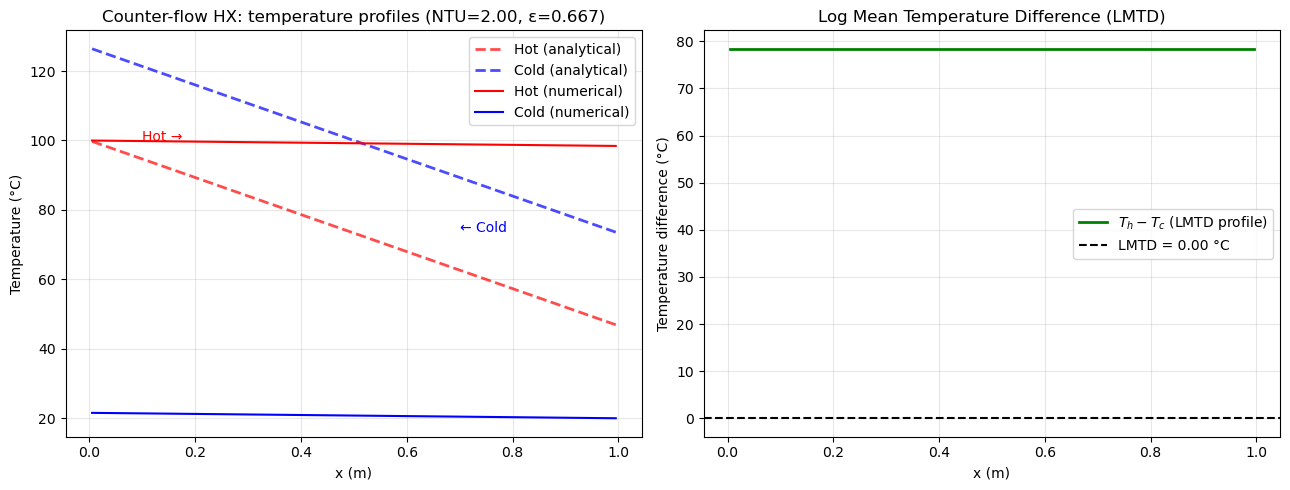

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1D counter-flow heat exchanger model
# Two streams (hot and cold) exchange heat through a wall of conductance UA
# Hot stream: left to right. Cold stream: right to left.

# Parameters
L      = 1.0     # exchanger length
N      = 100     # discretization points
dx     = L / N
x      = np.linspace(dx/2, L-dx/2, N)

# Thermal capacities (mass flow rate × specific heat)
Ch     = 1.0     # hot stream: mcp_hot
Cc     = 1.0     # cold stream: mcp_cold

# Overall heat transfer coefficient × area per unit length
UA_per_L = 2.0   # W/(m·K)

# Inlet temperatures
Th_in = 100.0    # hot inlet (left)
Tc_in = 20.0     # cold inlet (right)

# Analytical solution for counter-flow HX
# For equal Cmin = Cmax: T_h - T_c = const
NTU = UA_per_L * L / min(Ch, Cc)
eps = NTU / (1 + NTU)  # effectiveness for balanced counter-flow
Q_max = min(Ch, Cc) * (Th_in - Tc_in)
Q_actual = eps * Q_max

Th_out_exact = Th_in - Q_actual / Ch
Tc_out_exact = Tc_in + Q_actual / Cc

print(f"NTU = {NTU:.3f}")
print(f"Effectiveness ε = {eps:.4f}")
print(f"Q_actual = {Q_actual:.2f} W")
print(f"Hot outlet: {Th_out_exact:.2f} °C")
print(f"Cold outlet: {Tc_out_exact:.2f} °C")

# Numerical: 1D FVM energy balance
# Hot stream (marches left to right)
# Ch * dTh/dx = -UA_per_L * (Th - Tc)
# Cold stream (marches right to left — counter-flow)
# Cc * dTc/dx = UA_per_L * (Th - Tc)  [c flows right-to-left, but x is left-to-right]

# Build coupled system: implicit discretization
# 2N unknowns: [Th_0, ..., Th_{N-1}, Tc_0, ..., Tc_{N-1}]

A = np.zeros((2*N, 2*N))
b = np.zeros(2*N)

for i in range(N):
    # Hot stream (upwind left-to-right)
    A[i, i] = Ch/dx + UA_per_L*dx   # self
    if i > 0:
        A[i, i-1] = -Ch/dx           # upwind
    else:
        b[i] += Ch/dx * Th_in         # inlet BC
    A[i, N+i] = -UA_per_L*dx          # coupling to cold stream
    
    # Cold stream (upwind right-to-left → backward difference in x)
    A[N+i, N+i] = Cc/dx + UA_per_L*dx
    if i < N-1:
        A[N+i, N+i+1] = -Cc/dx
    else:
        b[N+i] += Cc/dx * Tc_in  # cold inlet (right)
    A[N+i, i] = -UA_per_L*dx     # coupling to hot stream

T_sol = np.linalg.solve(A, b)
Th_num = T_sol[:N]
Tc_num = T_sol[N:]

print(f"\nNumerical hot outlet: {Th_num[-1]:.2f} °C  (exact: {Th_out_exact:.2f})")
print(f"Numerical cold outlet: {Tc_num[0]:.2f} °C  (exact: {Tc_out_exact:.2f})")

# Analytical profiles for balanced counter-flow
# T_h(x) = Th_in - Q/Ch/L * x,  T_c(x) = Tc_out - Q/Cc/L * x
Th_analytical = Th_in - Q_actual/Ch/L * x
Tc_analytical = Tc_out_exact - Q_actual/Cc/L * (x - L)  # cold enters at x=L

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(x, Th_analytical, 'r--', linewidth=2, alpha=0.7, label='Hot (analytical)')
axes[0].plot(x, Tc_analytical, 'b--', linewidth=2, alpha=0.7, label='Cold (analytical)')
axes[0].plot(x, Th_num, 'r-',  linewidth=1.5, label='Hot (numerical)')
axes[0].plot(x, Tc_num, 'b-',  linewidth=1.5, label='Cold (numerical)')
axes[0].set_xlabel('x (m)'); axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title(f'Counter-flow HX: temperature profiles (NTU={NTU:.2f}, ε={eps:.3f})')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].annotate('Hot →', xy=(0.1, Th_analytical[0]), color='red', fontsize=10)
axes[0].annotate('← Cold', xy=(0.7, Tc_analytical[-1]), color='blue', fontsize=10)

# Temperature difference = driving force for heat transfer
dT = Th_num - Tc_num
axes[1].plot(x, dT, 'g-', linewidth=2, label='$T_h - T_c$ (LMTD profile)')
LMTD = (dT[0] - dT[-1]) / np.log(dT[0]/(dT[-1]+1e-6))
axes[1].axhline(LMTD, color='k', linestyle='--', label=f'LMTD = {LMTD:.2f} °C')
axes[1].set_xlabel('x (m)'); axes[1].set_ylabel('Temperature difference (°C)')
axes[1].set_title('Log Mean Temperature Difference (LMTD)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

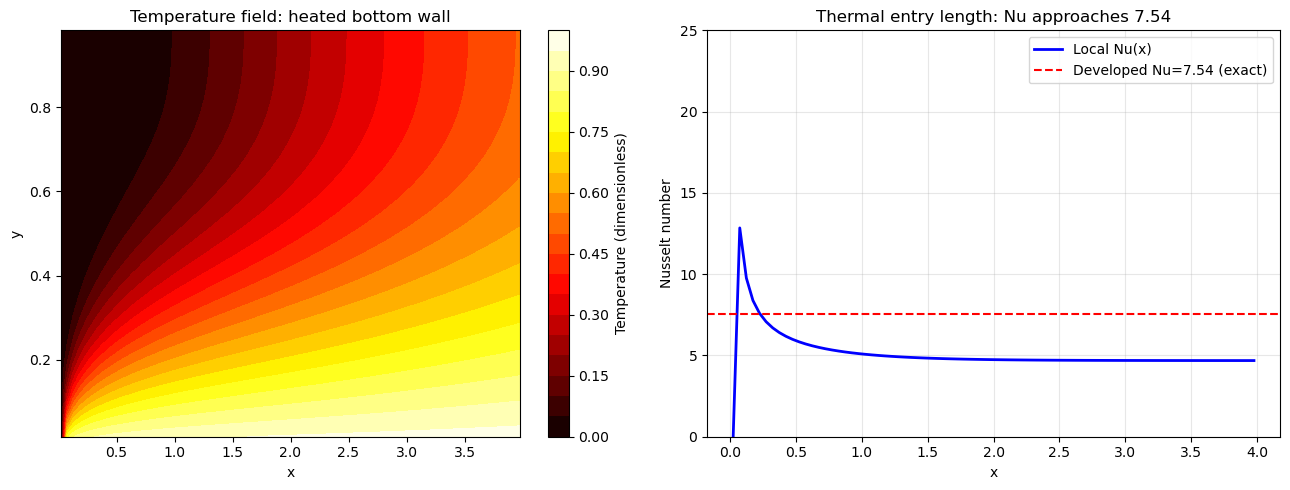

Thermal entry length ≈ 0.03 m
Inverse Graetz number at entry: x/(Dh*Pe) = 0.0013


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 2D conjugate heat transfer: flow over a heated plate
# Channel with bottom wall at T_hot, top insulated
# Show Nusselt number development along x

N_y, N_x = 30, 80
Lx, Ly = 4.0, 1.0
dx = Lx / N_x
dy = Ly / N_y
x  = np.linspace(dx/2, Lx - dx/2, N_x)
y  = np.linspace(dy/2, Ly - dy/2, N_y)
X, Y = np.meshgrid(x, y)

# Fully-developed Poiseuille velocity
H   = Ly / 2
U_b = 1.0
G   = 3*U_b / H**2  # to give bulk velocity U_b
U_pois = G * (H**2 - (y - H)**2) / 2  # parabolic, y goes 0 to 2H
# Normalise to give unit bulk velocity
U_pois *= U_b / (np.trapezoid(U_pois, y) / Ly)

# Temperature field: 2D advection-diffusion
alpha_f = 0.1   # thermal diffusivity
T_hot   = 1.0   # bottom wall temperature (dimensionless)
T_inlet = 0.0   # inlet temperature

T = np.ones((N_y, N_x)) * T_inlet

# March solution in x-direction (parabolic: downstream marching)
for ix in range(1, N_x):
    T_old = T[:, ix-1].copy()
    u_col = U_pois  # velocity at this x-slice

    # Advection-diffusion in y: implicit tridiagonal
    # u * dT/dx ≈ u*(T[:,ix]-T[:,ix-1])/dx = alpha * d²T/dy²
    D_y = alpha_f / dy**2
    A_col = np.zeros((N_y, N_y))
    b_col = np.zeros(N_y)

    for j in range(N_y):
        coeff = u_col[j] / dx
        A_col[j, j] = coeff + 2*D_y
        b_col[j]    = coeff * T_old[j]
        if j > 0:
            A_col[j, j-1] = -D_y
        else:
            # Bottom wall: T = T_hot (Dirichlet)
            b_col[0] += D_y * T_hot
        if j < N_y-1:
            A_col[j, j+1] = -D_y
        else:
            # Top wall: dT/dy = 0 (Neumann adiabatic)
            A_col[j, j] -= D_y

    T[:, ix] = np.linalg.solve(A_col, b_col)

# Compute local Nusselt number
# Nu = -k * dT/dy|_wall / (k * (T_w - T_b)) * Dh
Dh = 2*Ly  # hydraulic diameter for channel
T_b = np.array([np.trapezoid(U_pois*T[:,ix], y) / (U_b*Ly) for ix in range(N_x)])
dT_dy_wall = (T[1,:] - T[0,:]) / dy   # gradient at bottom wall
Nu_local = -dT_dy_wall * Dh / (T_hot - T_b + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cf = axes[0].contourf(X, Y, T, levels=20, cmap='hot')
plt.colorbar(cf, ax=axes[0], label='Temperature (dimensionless)')
axes[0].set_title('Temperature field: heated bottom wall')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

axes[1].plot(x, Nu_local, 'b-', linewidth=2, label='Local Nu(x)')
axes[1].axhline(7.54, color='r', linestyle='--', linewidth=1.5,
                label='Developed Nu=7.54 (exact)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('Nusselt number')
axes[1].set_title('Thermal entry length: Nu approaches 7.54')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 25)

plt.tight_layout()
plt.show()

# Find thermal entry length (where Nu first reaches within 5% of developed value)
Nu_dev = 7.54
i_dev = np.where(Nu_local < Nu_dev * 1.05)[0]
if len(i_dev) > 0:
    x_dev = x[i_dev[0]]
    Gz   = x_dev / (Dh * U_b / alpha_f)  # inverse Graetz number
    print(f"Thermal entry length ≈ {x_dev:.2f} m")
    print(f"Inverse Graetz number at entry: x/(Dh*Pe) = {Gz:.4f}")

## Key Takeaways

- Conjugate heat transfer couples fluid advection-diffusion with solid conduction.
- NTU-effectiveness method provides analytical validation for heat exchangers.
- Nusselt number $Nu$ measures dimensionless heat transfer: $Nu = hD_h/k$.
- Developed value: $Nu = 7.54$ for laminar channel with isothermal wall.
- The thermal entry length where temperature profile develops: $x_{th}/D_h \approx 0.05 Re \, Pr$.
